# version1:Separately apply this operation to each of the three input channels (i.e. the R, G, and B channels)

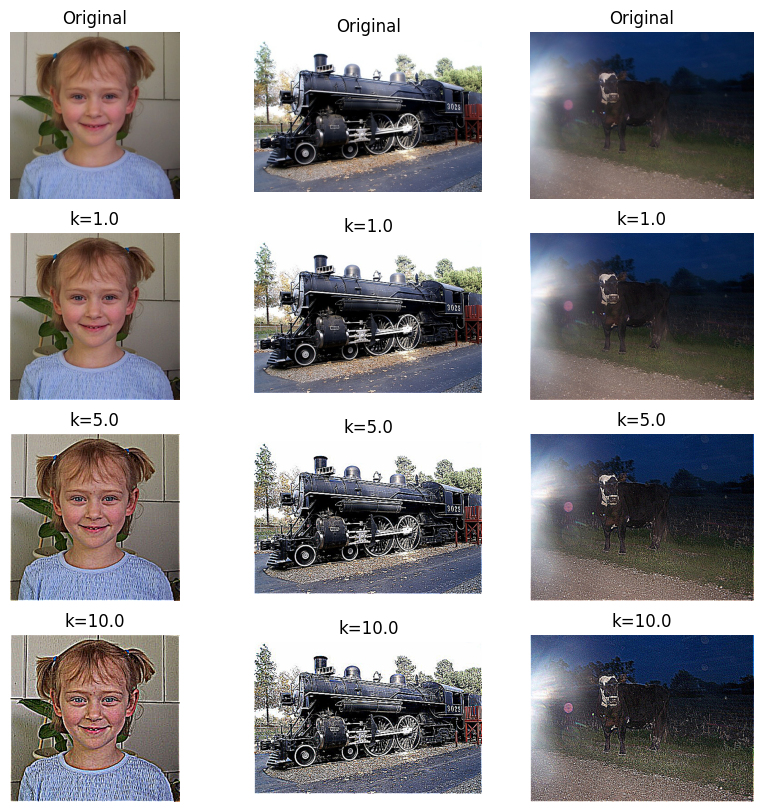

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 因為要拆出RGB通道並做捲積，in out channel改成1 groups=1
#(nn.Module)表示繼承自nn.Module
class DepthwiseConvModel(nn.Module):
    def __init__(self):
        super(DepthwiseConvModel, self).__init__()
        #in channel=3來接收RGB，group=3表示分成三組，每組處理一個通道，這樣每個通道都會使用相同的卷積核進行處理。
        self.conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=5, padding=2, groups=3,bias=False)
    #forward函數定義了模型的前向傳播過程，接受輸入x和強化參數k，返回增強後的圖像。
    def forward(self, x, k):
        x1 = self.conv(x)
        return x + k * (x - x1) # unsharp masking: 原圖 + k * (原圖-模糊)
# Load Image 
def readImageAndConvert(imageName):
    img = cv2.imread(imageName)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def imageEnhence(img, k):#接收圖片與強化參數k
    transform = transforms.ToTensor() 
    img_tensor=transform(img).unsqueeze(0) # [1,3,H,W]1是batch size，3是通道數，H和W是高度和寬度
    # 進行卷積處理
    with torch.no_grad():
        output = model(img_tensor, k)
    # Convert back to numpy for visualization
    result = output.squeeze().permute(1,2,0).numpy()#permute(1,2,0)將channel維度移到最後 來符合opencv
    result = np.clip(result * 255, 0, 255).astype(np.uint8)

    return result

#為了方便在subplot使用迴圈，因此存成list
images=["TestImage1.jpg", "TestImage2.jpg", "TestImage3.jpg"]
k_list=[1.0, 5.0, 10.0]
# 初始化模型
model = DepthwiseConvModel()
model.eval()

# 5x5 Gaussian kernel
gaussian_kernel = (1/256)*torch.tensor([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]], dtype=torch.float32)

#view函數改變tensor的形狀，repeat函數將單通道的卷積核複製成三個通道，
# 而其他通道重複1次，可以想成是乘法(1*3,1*1,5*1,5*1)
# 這樣每個RGB通道都會使用相同的高斯模糊核。
with torch.no_grad():
    #weight的參數是(out_channels, in_channels/groups, kernel_size[0], kernel_size[1])
    weight = gaussian_kernel.view(1, 1, 5, 5).repeat(3, 1, 1, 1)#[3,1,5,5]
    model.conv.weight.copy_(weight)

# Display original and processed image
plt.figure(figsize=(10,10))
#height=4 width=3
for col in range(3):
    img=readImageAndConvert(images[col])
    plt.subplot(4, 3, col+1)
    plt.imshow(img)
    plt.axis(False)
    plt.title('Original')
    for row in range(3):
        plt.subplot(4, 3, (row+1)*3+col+1)
        processed_img = imageEnhence(img, k_list[row])
        plt.imshow(processed_img)
        plt.axis(False)
        plt.title(f'k={k_list[row]}')
        
plt.show()


#version2: Convert the input image to the YUV color space, then apply this operation to the Y channel, and finally convert the enhanced image back to the RGB color space

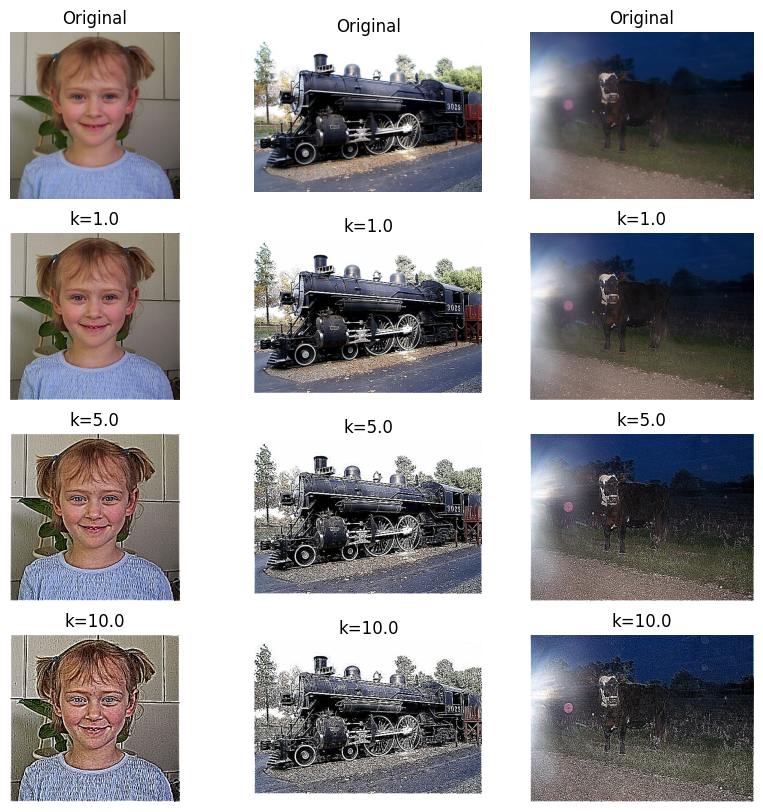

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Define the PyTorch Model
class ColorSpaceTransformModel(nn.Module):
    def __init__(self):
        super(ColorSpaceTransformModel, self).__init__()
        # RGB to YUV conversion (1x1 convolution)
        self.rgb2yuv = nn.Conv2d(3, 3, kernel_size=1, padding=0, bias=False)
        # Gaussian Blur (Depthwise 5x5 convolution)
        self.gaussian_blur = nn.Conv2d(1, 1, kernel_size=5, padding=2, bias=False)
        # YUV to RGB conversion (1x1 convolution)
        self.yuv2rgb = nn.Conv2d(3, 3, kernel_size=1, padding=0, bias=False)
    
    def forward(self, x, k):
        yuv = self.rgb2yuv(x)  # Convert RGB to YUV
        y_channel = yuv[:, :1, :, :]
        blurred_y = self.gaussian_blur(y_channel)  # Apply Gaussian Blur to Y channel
        enhanced_y = y_channel + (y_channel - blurred_y) * k   # Adjust Y channel
        yuv_transformed = torch.cat([enhanced_y, yuv[:, 1:, :, :]], dim=1)  # Recombine YUV channels
        output = self.yuv2rgb(yuv_transformed)  # Convert YUV back to RGB
        return output

# Load Image 
def readImageAndConvert(imageName):
    img = cv2.imread(imageName)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def imageEnhenceV2(img, k):
    # Convert image to tensor
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

    # Apply the model with k value
    with torch.no_grad():
        output = model(img_tensor, k)

    # Convert output back to numpy for visualization
    output_img = output.squeeze().permute(1, 2, 0).numpy()
    output_img = np.clip(output_img * 255, 0, 255).astype(np.uint8)
    return output_img
# Initialize Model
model = ColorSpaceTransformModel()
model.eval()  # Set to evaluation mode

images=["TestImage1.jpg", "TestImage2.jpg", "TestImage3.jpg"]
k_list=[1.0, 5.0, 10.0]

#rgb2yuv matrix
rgb2yuv_matrix = torch.tensor([[0.299, 0.587, 0.114],
                              [-0.14713, -0.28886, 0.436],
                                [0.615, -0.51499, -0.10001]], dtype=torch.float32)

yuv2rgb_matrix = torch.tensor([[1.0, 0.0, 1.13983],
                              [1.0, -0.39465, -0.58060],
                                [1.0, 2.03211, 0.0]], dtype=torch.float32)

# 5x5 Gaussian kernel
gaussian_kernel = (1/256)*torch.tensor([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]], dtype=torch.float32)

with torch.no_grad():
    #unsqueeze(2)表示在第2維新增一個維度
    model.rgb2yuv.weight.copy_(rgb2yuv_matrix.unsqueeze(2).unsqueeze(3))  # Reshape to [3,3,1,1]
    model.yuv2rgb.weight.copy_(yuv2rgb_matrix.unsqueeze(2).unsqueeze(3))  
    model.gaussian_blur.weight.copy_(gaussian_kernel.unsqueeze(0).unsqueeze(0))
    

# Display original and processed image
plt.figure(figsize=(10,10))
#height=4 width=3
for col in range(3):
    img=readImageAndConvert(images[col])
    plt.subplot(4, 3, col+1)
    plt.imshow(img)
    plt.axis(False)
    plt.title('Original')
    for row in range(3):
        plt.subplot(4, 3, (row+1)*3+col+1)
        processed_img = imageEnhenceV2(img, k_list[row])
        plt.imshow(processed_img)
        plt.axis(False)
        plt.title(f'k={k_list[row]}')
        
plt.show()
